## objectives
- Create a pytorch dataset from the squared image folder
- Load imagent1k weights for resnet50 as a baseline

In [1]:
from collections import Counter

import os
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode



In [2]:
data_dir = '/home/takayuki/Desktop/summer2025/plants/data/AquaticPlantLabData/squared'

train_percent = 0.8
batch_size = 2

random_seed = 8

In [3]:
torch.manual_seed(random_seed)

# basic_tf = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    
# ])

aug_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.5, 1.0), ratio=(1.0, 1.0)),
    
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.01),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.5, interpolation=InterpolationMode.BICUBIC),    
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


dataset = datasets.ImageFolder(data_dir, transform = aug_tf)

train_size = int(train_percent * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size], 
                                                              generator=torch.Generator().manual_seed(random_seed))
train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size, shuffle=False)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}\n")

# print how many images and of which classes are in the train and test datasets

def count_classes(subset):
    labels = [subset.dataset.targets[i] for i in subset.indices]
    label_counts = Counter(labels)
    return label_counts

train_class_counts = count_classes(train_dataset)
test_class_counts = count_classes(test_dataset)
class_names = dataset.classes
max_len = max(len(name) for name in class_names)
for i, class_name in enumerate(class_names):
    train_count = train_class_counts.get(i, 0)
    test_count = test_class_counts.get(i, 0)
    class_name = class_name.ljust(max_len+1)
    print(f"{class_name}: Train: {train_count}\t, Test: {test_count}")


Train dataset size: 172
Test dataset size: 43

Brasenia schreberi       : Train: 6	, Test: 3
Cabomba                  : Train: 2	, Test: 3
Ceratophyllum demersum   : Train: 21	, Test: 0
Elodea canadensis        : Train: 11	, Test: 4
Heteranthera dubia       : Train: 6	, Test: 1
Hydrocharis morsus-ranae : Train: 8	, Test: 4
Myriophyllum sibiricum   : Train: 4	, Test: 0
Myriophyllum spicatum    : Train: 12	, Test: 1
Najas flexilis           : Train: 4	, Test: 1
Nitellopsis obtusa       : Train: 3	, Test: 1
Nuphar variegata         : Train: 3	, Test: 0
Nymphaea odorata         : Train: 2	, Test: 0
Potamogeton crispus      : Train: 15	, Test: 6
Potamogeton gramineus    : Train: 13	, Test: 4
Potamogeton illinoensis  : Train: 29	, Test: 6
Potamogeton natans       : Train: 8	, Test: 1
Potamogeton praelongus   : Train: 3	, Test: 0
Potamogeton richardsonii : Train: 4	, Test: 2
Potamogeton robbinsii    : Train: 7	, Test: 2
Ranunculus aquatilis     : Train: 3	, Test: 2
Vallisneria americana    : 

## Load pretrained model
- ResNet50 with ImageNet1K weights

In [4]:
from tqdm import tqdm
from datetime import datetime

import timm
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
from torchinfo import summary

In [5]:
# list models available in timm
timm.list_models('*convnextv2*', pretrained=True)

['convnextv2_atto.fcmae',
 'convnextv2_atto.fcmae_ft_in1k',
 'convnextv2_base.fcmae',
 'convnextv2_base.fcmae_ft_in1k',
 'convnextv2_base.fcmae_ft_in22k_in1k',
 'convnextv2_base.fcmae_ft_in22k_in1k_384',
 'convnextv2_femto.fcmae',
 'convnextv2_femto.fcmae_ft_in1k',
 'convnextv2_huge.fcmae',
 'convnextv2_huge.fcmae_ft_in1k',
 'convnextv2_huge.fcmae_ft_in22k_in1k_384',
 'convnextv2_huge.fcmae_ft_in22k_in1k_512',
 'convnextv2_large.fcmae',
 'convnextv2_large.fcmae_ft_in1k',
 'convnextv2_large.fcmae_ft_in22k_in1k',
 'convnextv2_large.fcmae_ft_in22k_in1k_384',
 'convnextv2_nano.fcmae',
 'convnextv2_nano.fcmae_ft_in1k',
 'convnextv2_nano.fcmae_ft_in22k_in1k',
 'convnextv2_nano.fcmae_ft_in22k_in1k_384',
 'convnextv2_pico.fcmae',
 'convnextv2_pico.fcmae_ft_in1k',
 'convnextv2_tiny.fcmae',
 'convnextv2_tiny.fcmae_ft_in1k',
 'convnextv2_tiny.fcmae_ft_in22k_in1k',
 'convnextv2_tiny.fcmae_ft_in22k_in1k_384']

In [ ]:
model_name = "convnextv2_base.fcmae_ft_in22k_in1k"

# model = timm.create_model('tf_efficientnetv2_b0.in1k', pretrained=True)
# model = timm.create_model('convnextv2_tiny.fcmae_ft_in22k_in1k', pretrained=True)
# model = timm.create_model('swinv2_cr_tiny_ns_224.sw_in1k', pretrained=True)
# model = timm.create_model('focalnet_tiny_srf.ms_in1k', pretrained=True)
# model = timm.create_model('convnextv2_base.fcmae_ft_in22k_in1k', pretrained=True)

model = timm.create_model(model_name, pretrained=True)
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                                       Output Shape              Param #
ConvNeXt                                                     [1, 1000]                 --
├─Sequential: 1-1                                            [1, 96, 56, 56]           --
│    └─Conv2d: 2-1                                           [1, 96, 56, 56]           4,704
│    └─LayerNorm2d: 2-2                                      [1, 96, 56, 56]           192
├─Sequential: 1-2                                            [1, 768, 7, 7]            --
│    └─ConvNeXtStage: 2-3                                    [1, 96, 56, 56]           --
│    │    └─Identity: 3-1                                    [1, 96, 56, 56]           --
│    │    └─Sequential: 3-2                                  [1, 96, 56, 56]           239,904
│    └─ConvNeXtStage: 2-4                                    [1, 192, 28, 28]          --
│    │    └─Sequential: 3-3                                  [1, 192, 28, 28]         

In [7]:
print(model)

ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (mlp): GlobalResponseNormMlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (grn): GlobalResponseNorm()
            (fc2): Linear(in_features=384, out_features=96, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), 

In [8]:
old_classifier = model.get_classifier()
new_classifier = nn.Linear(old_classifier.in_features, len(dataset.classes))

for param in model.parameters():
    param.requires_grad = False

for param in new_classifier.parameters():
    param.requires_grad = True

model.reset_classifier(num_classes=len(dataset.classes)) 

print("Number of trainable parameters: ", sum(p.numel() for p in model.parameters() if p.requires_grad))

Number of trainable parameters:  16149


## Training Loop
- Tensorboard logging
- Save model checkpoints
- Save best models

In [9]:
# Parameters
run_name = "rechecking convnextv2_tiny_fcmae_ft_in22k_in1k"
learning_rate = 0.0001
num_epochs = 100

checkpoint_interval = 7
validation_interval = 1

# Paths
checkpoint_path = "/home/takayuki/Desktop/summer2025/plants/training/checkpoints"
models_path = "/home/takayuki/Desktop/summer2025/plants/training/models"
base_logs_path = "/home/takayuki/Desktop/summer2025/plants/training/runs/convnextv2"

os.makedirs(checkpoint_path, exist_ok=True)
os.makedirs(models_path, exist_ok=True)
os.makedirs(base_logs_path, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
print(f"Using device: {device}, {torch.cuda.get_device_name(device) if device.type == 'cuda' else 'CPU'}")

Using device: cuda, NVIDIA RTX A500 Laptop GPU


In [10]:
criterion = nn.CrossEntropyLoss()
trainable_params = filter(lambda p: p.requires_grad, model.parameters())
optimizer = torch.optim.AdamW(trainable_params, lr=learning_rate)

now = datetime.now()
timestamp = now.strftime("%m-%d_%H-%M--%S")

# model_name = model.name if hasattr(model, 'name') else model.__class__.__name__

hparams_dict = {
    "a_run_name": run_name,
    "learning_rate": learning_rate,
    "num_epochs": num_epochs,
    "batch_size": batch_size,
    "train_dataset_size": len(train_dataset),
    "test_dataset_size": len(test_dataset),
    "model_architecture": model_name,
    "optimizer": optimizer.__class__.__name__,
    "criterion": criterion.__class__.__name__,
    "timestamp": timestamp,
}

writer = SummaryWriter(log_dir=os.path.join(base_logs_path, f"{timestamp}_{run_name}_{model_name}"))

for key, value in hparams_dict.items():
    writer.add_text(key, str(value))

# Training loop
best_val_accuracy = 0.0
best_val_epoch = 0

print("Starting training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{num_epochs}", unit="batch"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / total
    train_accuracy = correct / total
    
    print(f"Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy*100:.4f}%")
    
    writer.add_scalar('Loss/train', train_loss, epoch)
    writer.add_scalar('Accuracy/train', train_accuracy, epoch)
    
    # Validation phase
    if (epoch + 1) % validation_interval == 0:
        model.eval()  
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():  
            
            for val_images, val_labels in test_dataloader:
                val_images, val_labels = val_images.to(device), val_labels.to(device)
                
                val_outputs = model(val_images)
                val_loss = criterion(val_outputs, val_labels)
                
                val_running_loss += val_loss.item() * val_images.size(0)
                _, val_predicted = torch.max(val_outputs.data, 1)
                val_total += val_labels.size(0)
                val_correct += (val_predicted == val_labels).sum().item()
        
        val_loss = val_running_loss / val_total
        val_accuracy = val_correct / val_total

        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy*100:.4f}%")
        
        writer.add_scalar('Loss/validation', val_loss, epoch)
        writer.add_scalar('Accuracy/validation', val_accuracy, epoch)
        
        # best model
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_val_epoch = epoch + 1
            
            # Delete previous best model if exists
            best_model_name = f"best_model_{timestamp}_{run_name}_{model_name}.pth"
            best_model_file_path = os.path.join(models_path, best_model_name)
            
            if os.path.exists(best_model_file_path):
                os.remove(best_model_file_path)
            
            # Save the new one
            torch.save(model.state_dict(), best_model_file_path)
            print(f"Saved new best model: {best_model_file_path}")
        
        
        
        
    # Checkpoint saving phase
    if (epoch + 1) % checkpoint_interval == 0:
        checkpoint_name = f"checkpoint_{timestamp}_{run_name}_{model_name}_epoch_{epoch + 1}.pth"
        checkpoint_file_path = os.path.join(checkpoint_path, checkpoint_name)
        
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss, 
            'log_dir': writer.log_dir,
            'best_val_accuracy': best_val_accuracy,
            'best_val_epoch': best_val_epoch,
            'hparams': hparams_dict
        }, checkpoint_file_path)
        
        print(f"Saved checkpoint: {checkpoint_file_path}")

print("\nTraining complete.")
print(f"Best Validation Accuracy: {best_val_accuracy*100:.4f}% at Epoch {best_val_epoch}")
print(f"Final Training Accuracy: {train_accuracy*100:.4f}%")
print("\nRun ID: ")
print(f"{timestamp}_{run_name}_{model_name}")
  

Starting training...


Epoch 1/100: 100%|██████████| 86/86 [00:17<00:00,  4.88batch/s]


Training Loss: 2.9461, Training Accuracy: 9.3023%
Validation Loss: 2.6823, Validation Accuracy: 23.2558%
Saved new best model: /home/takayuki/Desktop/summer2025/plants/training/models/best_model_06-19_17-36--23_rechecking convnextv2_tiny_fcmae_ft_in22k_in1k_ConvNeXt.pth


Epoch 2/100: 100%|██████████| 86/86 [00:16<00:00,  5.12batch/s]


Training Loss: 2.4395, Training Accuracy: 28.4884%
Validation Loss: 2.4658, Validation Accuracy: 30.2326%
Saved new best model: /home/takayuki/Desktop/summer2025/plants/training/models/best_model_06-19_17-36--23_rechecking convnextv2_tiny_fcmae_ft_in22k_in1k_ConvNeXt.pth


...

Training Loss: 0.0410, Training Accuracy: 100.0000%
Validation Loss: 0.4116, Validation Accuracy: 88.3721%
Saved checkpoint: /home/takayuki/Desktop/summer2025/plants/training/checkpoints/checkpoint_06-19_17-36--23_rechecking convnextv2_tiny_fcmae_ft_in22k_in1k_ConvNeXt_epoch_98.pth


Epoch 99/100: 100%|██████████| 86/86 [00:21<00:00,  4.07batch/s]


Training Loss: 0.0506, Training Accuracy: 98.8372%
Validation Loss: 0.5525, Validation Accuracy: 83.7209%


Epoch 100/100: 100%|██████████| 86/86 [00:20<00:00,  4.10batch/s]


Training Loss: 0.0531, Training Accuracy: 99.4186%
Validation Loss: 0.4433, Validation Accuracy: 88.3721%

Training complete.
Best Validation Accuracy: 90.6977% at Epoch 53
Final Training Accuracy: 99.4186%

Run ID: 
06-19_17-36--23_rechecking convnextv2_tiny_fcmae_ft_in22k_in1k_ConvNeXt


In [11]:
print("\nTraining complete.")
print(f"Best Validation Accuracy: {best_val_accuracy*100:.4f}% at Epoch {best_val_epoch}")
print(f"Final Training Accuracy: {train_accuracy*100:.4f}%")
print("\nRun ID: ")
print(f"{timestamp}_{run_name}_{model_name}")


Training complete.
Best Validation Accuracy: 90.6977% at Epoch 53
Final Training Accuracy: 99.4186%

Run ID: 
06-19_17-36--23_rechecking convnextv2_tiny_fcmae_ft_in22k_in1k_ConvNeXt


In [12]:
observations = f"Reruning it retraces the exact same training logs"
    
hparams_dict["observations"] = observations
writer.add_text('Observations', observations)

# Save the final model
final_model_name = f"final_model_{model_name}_{timestamp}.pth"
final_model_file_path = os.path.join(models_path, final_model_name)
torch.save(model.state_dict(), final_model_file_path)
print(f"Saved final model: {final_model_file_path}")

# Write Metrics and Hyperparameters to TensorBoard
metrics = {
    "epochs_trained": epoch + 1,
    "final_train_loss": train_loss,
    "final_train_accuracy": train_accuracy,
    "final_val_loss": val_loss,
    "final_val_accuracy": val_accuracy,
    "best_val_accuracy": best_val_accuracy,
    "best_val_epoch": best_val_epoch,
}
writer.add_hparams(hparams_dict, metrics)
writer.flush()
writer.close()  

Saved final model: /home/takayuki/Desktop/summer2025/plants/training/models/final_model_ConvNeXt_06-19_17-36--23.pth


## Evaluation script

In [ ]:
import torch
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import os

def evaluate_model_on_test_set(model_to_evaluate, dataloader, current_device, class_names_list):
    print("\nStarting evaluation on the test set...")
    model_to_evaluate.eval()  

    all_predictions = []
    all_true_labels = []

    with torch.no_grad():
        for batch_idx, (images, labels) in tqdm(enumerate(dataloader), total=len(dataloader), desc="Evaluating", unit="batch"):
            images = images.to(current_device)
            labels = labels.to(current_device)

            outputs = model_to_evaluate(images)
            _, predicted_classes = torch.max(outputs, 1) 

            all_predictions.extend(predicted_classes.cpu().numpy())
            all_true_labels.extend(labels.cpu().numpy())


    print("\n--- Test Set Evaluation Results ---")

    accuracy = accuracy_score(all_true_labels, all_predictions)
    print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    print("\nClassification Report:")
    report_labels_indices = list(range(len(class_names_list)))
    print(classification_report(all_true_labels, all_predictions,
                                labels=report_labels_indices,
                                target_names=class_names_list,
                                zero_division=0)) 

    print("\nConfusion Matrix:")
    cm = confusion_matrix(all_true_labels, all_predictions, labels=report_labels_indices)
    print(cm)

    plt.figure(figsize=(max(8, len(class_names_list)*0.6), max(6, len(class_names_list)*0.5)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names_list,
                yticklabels=class_names_list)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(f"Confusion Matrix - Model: {model_name}")
    plt.tight_layout() 
    
    return accuracy, all_true_labels, all_predictions

#### Some evaluation metrics
- Accuracy: correct predictions / total predictions
- Precision: TP / (TP + FP)
- Recall: TP / (TP + FN)
- F1 Score: Harmonic mean of precision and recall


Starting evaluation on the test set...


Evaluating: 100%|██████████| 22/22 [00:04<00:00,  4.50batch/s]



--- Test Set Evaluation Results ---
Overall Accuracy: 0.9070 (90.70%)

Classification Report:
                          precision    recall  f1-score   support

      Brasenia schreberi       0.75      1.00      0.86         3
                 Cabomba       1.00      0.67      0.80         3
  Ceratophyllum demersum       0.00      0.00      0.00         0
       Elodea canadensis       0.80      1.00      0.89         4
      Heteranthera dubia       0.50      1.00      0.67         1
Hydrocharis morsus-ranae       1.00      0.75      0.86         4
  Myriophyllum sibiricum       0.00      0.00      0.00         0
   Myriophyllum spicatum       1.00      1.00      1.00         1
          Najas flexilis       1.00      1.00      1.00         1
      Nitellopsis obtusa       1.00      1.00      1.00         1
        Nuphar variegata       0.00      0.00      0.00         0
        Nymphaea odorata       0.00      0.00      0.00         0
     Potamogeton crispus       1.00      1.00 

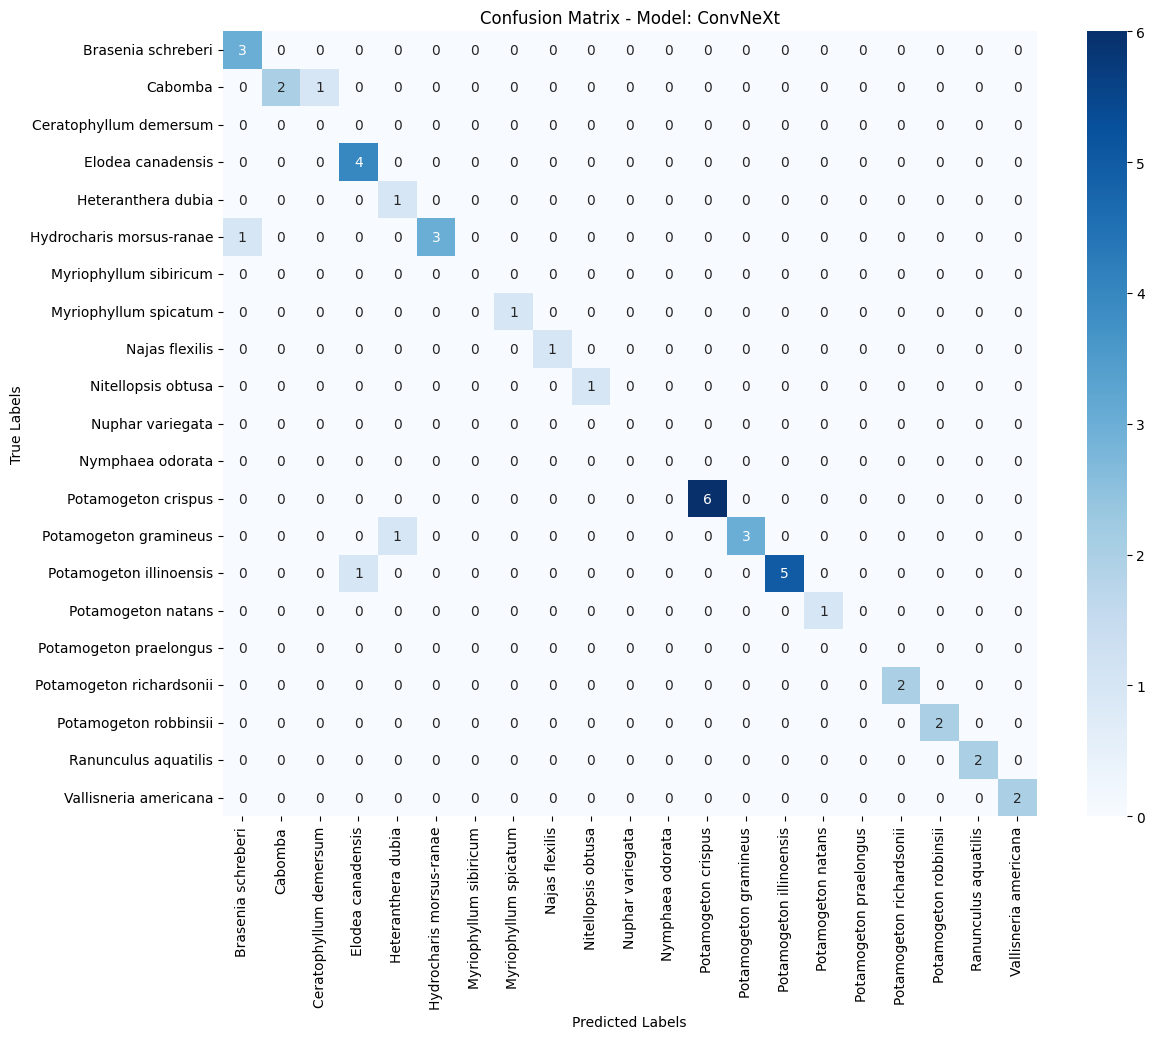

In [32]:
test_accuracy, true_labels, predictions = evaluate_model_on_test_set(model, test_dataloader, device, dataset.classes)